In [64]:
#Import Relevant Modules
import re
from datetime import datetime, date
from time import sleep
import csv
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import clear_output
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import json
import ipywidgets as widgets

In [ ]:
# Define global variables and settings

# Log file location on laptop: 'C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-Logs/*'
# Tera term log file location on laptop: 'C:/Users/Experiment/cbmark_logger/Tera Term logs/*'
# WebMonitor log file location on laptop : 'C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-WMLogs/*'

# ================= File paths for log files =================
blank_path = "Data samples/Blank.txt"
dashboard_log_path      = "Data samples/log_2025-07-08_14-18-35.txt"
teraTerm_log_path902b   = "Data samples/Blank.txt"
teraTerm_log_path20kv   = "Data samples/Tera Term log 2025-07-07.txt"
teraTerm_log_path3kv    = "Data samples/Tera Term log 2025-07-07.txt"
teraTerm_log_pathPos1kv = "Data samples/Tera Term log 2025-07-07.txt"
teraTerm_log_pathNeg1kv = "Data samples/Tera Term log 2025-07-07.txt"
webMonitor_path         = "webMonitor_log.txt"
# ============================================================

# Positive number of previous webMonitor files to read at first initialization
# Select 0 to use only most recent WM file
numInitWMFiles = 3

# Keep last N minutes of WebMonitor data in memory (set to None to keep everything).
WEBMONITOR_WINDOW_MINUTES = None

# This stores the names for each subplot and line in the subplot
graph_settings = {
    'PMON temperatures': {
        "lines" : ["pmon1", "pmon2", "pmon3", "pmon4", "pmon5", "pmon6"],
        "unit": "°C",
        "enabled": True
    },
    'CCS temperatures': {
        "lines": ["ccs_A_temp", "ccs_B_temp", "ccs_C_temp"],
        "unit": "°C",
        "enabled": True
    },
    'Chamber pressure': {
        "lines": ["vtrx_pressure"],
        "unit": "mbar",
        "enabled": True
    },
    'CCS voltages': {
        "lines": ["ccs_A_voltage", "ccs_B_voltage", "ccs_C_voltage"],
        "unit": "V",
        "enabled": True
    },
    'CCS currents': {
        "lines": ["ccs_A_current", "ccs_B_current", "ccs_C_current"],
        "unit": "A",
        "enabled": True
    }
}

legacy_graph_settings = {
    '20kV PSU voltage':   {
        "lines": ['hvActualVolt20kv', 'hvSetVolt20kv'],
        "unit": "V",
        "enabled": False
    },
    '20kV PSU current':   {
        "lines": ['hvCurrent20kv'],
        "unit": "mA",
        "enabled": False
    },
    '3kV PSU voltage':    {
        "lines": ['hvActualVolt3kv', 'hvSetVolt3kv'],
        "unit": "V",
        "enabled": False
    },
    '3kV PSU current':    {
        "lines": ['hvCurrent3kv'],
        "unit": "mA",
        "enabled": False
    },
    'pos1kV PSU voltage': {
        "lines": ['hvActualVoltPos1kv', 'hvSetVoltPos1kv'],
        "unit": "V",
        "enabled": False
    },
    'pos1kV PSU current': {
        "lines": ['hvCurrentPos1kv'],
        "unit": "mA",
        "enabled": False
    },
    'neg1kV PSU voltage': {
        "lines": ['hvActualVoltNeg1kv', 'hvSetVoltNeg1kv'],
        "unit": "V",
        "enabled": False
    },
    'neg1kV PSU current': {
        "lines": ['hvCurrentNeg1kv'],
        "unit": "mA",
        "enabled": False
    },
    # CCS Set voltage/current logging have been changed since the original code was written
    # These settings do not currently work
    # 'CCS Set Voltage':    {
    #     "lines": ['ccsSetVoltage'],
    #     "unit": "V",
    #     "enabled": False
    # },
    # 'CCS Set Current':    {
    #     "lines": ['ccsSetCurrent'],
    #     "unit": "A",
    #     "enabled": False
    # }
}

# Lookup for how many y-axis ticks to use based on the number of plots
num_y_ticks = [
    0, # 0 plots
    0, # 1 plot (can't do just 1 plot with this method)
    20, # 2 plots
    10, # 3 plots
    10, # 4 plots
    7, # 5 plots
    3, # 6 plots
    3, # 7 plots
    3, # 8 plots
    3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3 
] 




# Internal state for incremental reads:
# - path: last filename read (used to detect log rotation / filename change)
# - pos: byte offset within the file
# - remainder: trailing partial line (bytes) when the writer hasn't flushed a newline yet
_webmon_tail_state = {"path": None, "pos": 0, "remainder": b""}
_webmon_cache_df = pd.DataFrame()
# ==========================================================


In [66]:
# Define functions
def _read_appended_json_lines(path, state):
        # Detect filename change (log rotation) and restart reading from the beginning
        # of the new file. We intentionally do NOT clear _webmon_cache_df here, so
        # plots can show continuity across files.
        if state["path"] != path:
            state["path"] = path
            state["pos"] = 0
            state["remainder"] = b""

        try:
            size = os.path.getsize(path)
        except OSError:
            return []

        # If the file shrank, it was replaced/truncated: reset to the start.
        if size < state["pos"]:
            state["pos"] = 0
            state["remainder"] = b""

        # Read only the bytes appended since the last call.
        with open(path, "rb") as f:
            f.seek(state["pos"])
            chunk = f.read()
            state["pos"] = f.tell()

        if not chunk:
            return []

        # Prepend any partial line we carried over from last time, then split by newline.
        data = state["remainder"] + chunk
        parts = data.split(b"\n")

        # If the writer didn't end with a newline, keep the last fragment for next time.
        if data.endswith(b"\n"):
            state["remainder"] = b""
            complete = parts[:-1]
        else:
            state["remainder"] = parts[-1]
            complete = parts[:-1]

        lines = []
        for bline in complete:
            bline = bline.strip()
            if not bline:
                continue
            try:
                lines.append(bline.decode("utf-8"))
            except UnicodeDecodeError:
                lines.append(bline.decode("utf-8", errors="replace"))
        return lines

# This function extracts data from the web monitor log file, which is in JSON format
# It outputs a pandas DataFrame with a timestamp index and columns for each sensor reading
def getDataFromWebMonitorFile(filename):
    # Incremental (tail) parser.
    # Returns a cached DataFrame that grows as the file grows (then is trimmed to a
    # rolling time window via WEBMONITOR_WINDOW_MINUTES).
    global _webmon_tail_state
    global _webmon_cache_df

    if not filename:
        return _webmon_cache_df

    # Pull only newly appended, complete JSON lines.
    new_lines = _read_appended_json_lines(filename, _webmon_tail_state)
    if not new_lines:
        return _webmon_cache_df

    # Parse JSON objects and flatten them into row dictionaries.
    records = []
    for line in new_lines:
        try:
            data = json.loads(line)
        except json.JSONDecodeError:
            continue

        status = data["status"]
        temps = status["temperatures"]

        record = {
            "timestamp": data["timestamp"],
            "vtrx_pressure": status["pressure"],
            "pmon1": temps["1"],
            "pmon2": temps["2"],
            "pmon3": temps["3"],
            "pmon4": temps["4"],
            "pmon5": temps["5"],
            "pmon6": temps["6"],
            "ccs_A_temp": status["clamp_temperature_A"],
            "ccs_B_temp": status["clamp_temperature_B"],
            "ccs_C_temp": status["clamp_temperature_C"],
            "ccs_A_current": status["Cathode A - Heater Current:"],
            "ccs_B_current": status["Cathode B - Heater Current:"],
            "ccs_C_current": status["Cathode C - Heater Current:"],
            "ccs_A_voltage": status["Cathode A - Heater Voltage:"],
            "ccs_B_voltage": status["Cathode B - Heater Voltage:"],
            "ccs_C_voltage": status["Cathode C - Heater Voltage:"]
        }
        records.append(record)

    if not records:
        return _webmon_cache_df

    # Convert to DataFrame and normalize types used by plotting.
    new_df = pd.DataFrame(records)
    if new_df.empty:
        return _webmon_cache_df

    new_df["timestamp"] = pd.to_datetime(new_df["timestamp"], errors="coerce")
    new_df = new_df.dropna(subset=["timestamp"])

    for subplot in graph_settings :
        for col in graph_settings[subplot]["lines"] :
            if col in new_df.columns:
                new_df[col] = pd.to_numeric(new_df[col], errors="coerce")

    new_df = new_df.set_index("timestamp")

    # Append new rows into the cache.
    if _webmon_cache_df is None or _webmon_cache_df.empty:
        _webmon_cache_df = new_df
    else:
        _webmon_cache_df = pd.concat([_webmon_cache_df, new_df])

    # Keep index ordered and dedupe timestamps (last write wins).
    _webmon_cache_df = _webmon_cache_df.sort_index()
    _webmon_cache_df = _webmon_cache_df[~_webmon_cache_df.index.duplicated(keep="last")]

    # Enforce a rolling time window so memory/plotting time stays bounded.
    if WEBMONITOR_WINDOW_MINUTES is not None and not _webmon_cache_df.empty:
        cutoff = _webmon_cache_df.index.max() - pd.Timedelta(minutes=WEBMONITOR_WINDOW_MINUTES)
        _webmon_cache_df = _webmon_cache_df[_webmon_cache_df.index >= cutoff]

    return _webmon_cache_df


# This function extracts pressure data from the 902b log file, which is in a custom text format
# It outputs a dataframe with a timestamp index and a column for pressure readings

# This is a remnant of IC's first revision of the code, which was based on code from ND
# This function uses regex, so it is a bit slow and should be called on only if needed (i.e. if the 902b pressure graph is enabled)
# If it stops parsing correctly, print the lines being read and use regex101.com to debug the regex string
def get902bPressureData(filename):
    '''
    Extract pressure data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of Time and Pressure -> list
    '''
    
    # Create an empty list to store the extracted data before converting it to a DataFrame
    data = []                          
    # Regex pattern to parse lines in the 902b log file for timestamps and pressure readings
    regex_pattern = re.compile(r'\[\d{4}-\d{2}-\d{2} (\d{2}:\d{2}:\d{2})\.\d{3}\] @\d{3}ACK(\d*\.\d*);FF', re.I)
    # Columns for the DataFrame
    columns=["Time", "Pressure (mbar)"]
    
    with open(filename, "r") as f:
        for line in f:
            p = regex_pattern.search(line)
            if p:
                time_str = p.group(1)
                pressure = p.group(2)

                data.append((time_str, pressure))
                
    # Convert the list of tuples into a DataFrame and convert data types
    df = pd.DataFrame(data, columns=columns)
    if(not df.empty) :
        df['Time'] = pd.to_datetime(df['Time'].astype(str), format = "mixed")

        for col in range(1, len(columns)) :
            df[columns[col]] = pd.to_numeric(df[columns[col]])

    return df

# This function extracts ccs voltage set data from the dashboard log file
# It outputs a dataframe with a timestamp index and a column for voltage set point readings

# This is a remnant of IC's first revision of the code, which was based on code from ND
# This function uses regex on a huge file, so it is pretty slow and should be called on only if needed (i.e. if the CCS voltage set graph is enabled)
# If it stops parsing correctly, print the lines being read and use regex101.com to debug the regex string

# This is not currently working because CCS set point logging was changed significantly
# def getCCSVoltageSetData(filename):
    '''
    Extract voltage data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of Time and Voltage -> list
    '''
    
    # Create an empty list to store the extracted data before converting it to a DataFrame
    data = []                
    # Regex pattern to parse lines in the dashboard file for timestamps and voltage set points
    regex_pattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?INFO: Voltage set to (\d*\.\d*)', re.I)
    # Columns for the DataFrame
    columns=["Time", "ccsSetVoltage"]

    with open(filename, "r") as f:
        for line in f:
            p = regex_pattern.search(line)
            if p:
                time_str = p.group(1)
                setPoint = p.group(2)

                data.append((time_str, setPoint))

    # Convert the list of tuples into a DataFrame and convert data types
    df = pd.DataFrame(data, columns=columns)
    if(not df.empty) :
        df['Time'] = pd.to_datetime(df['Time'].astype(str), format = "mixed")

        for col in range(1, len(columns)) :
            df[columns[col]] = pd.to_numeric(df[columns[col]])

    return df



# This function extracts ccs current set data from the dashboard log file
# It outputs a dataframe with a timestamp index and a column for current set point readings

# This is a remnant of IC's first revision of the code, which was based on code from ND
# This function uses regex on a huge file, so it is pretty slow and should be called on only if needed (i.e. if the CCS current set graph is enabled)
# If it stops parsing correctly, print the lines being read and use regex101.com to debug the regex string

# This is not currently working because CCS set point logging was changed significantly
# def getCCSCurrentSetData(filename):
    '''
    Extract current data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of Time and Current -> list
    '''
    
    # Create an empty list to store the extracted data before converting it to a DataFrame
    data = []                          
    # Regex pattern to parse lines in the dashboard file for timestamps and current set points
    regex_pattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?INFO: Current set to (\d*\.\d*)', re.I)
    # Columns for the DataFrame
    columns=["Time", "ccsSetCurrent"]
    
    with open(filename, "r") as f:
        for line in f:
            p = regex_pattern.search(line)
            if p:
                time_str = p.group(1)
                setPoint = p.group(2)

                data.append((time_str, setPoint))


    # Convert the list of tuples into a DataFrame and convert data types
    df = pd.DataFrame(data, columns=columns)
    if(not df.empty) :
        df['Time'] = pd.to_datetime(df['Time'].astype(str), format = "mixed")

        for col in range(1, len(columns)) :
            df[columns[col]] = pd.to_numeric(df[columns[col]])

    return df


# This function extracts HV PSU data from Tera Term HV Monitor log files, which are in a custom text format
# It outputs a dataframe with a timestamp index and columns for voltage set point, voltage actual, and current readings for the specified PSU

# This is a remnant of IC's first revision of the code, which was based on code from ND
# This function uses regex on a huge file, so it is pretty slow and should be called on only if needed (i.e. if one of the HV graphs are enabled)
# If it stops parsing correctly, print the lines being read and use regex101.com to debug the regex string
def getHVData(filename, psu_type = "3kv"):
    '''
    Extract pressure data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of time and HV current -> list
    '''
    
    # Create an empty list to store the extracted data before converting it to a DataFrame
    data = []                          
    # Regex pattern to parse lines in the Tera Term log file for timestamps and HV PSU readings (voltage set point, voltage actual, and current)
    regex_pattern = re.compile(r'\[\d{4}-\d{2}-\d{2} (.*?)\] Set: -?(\d{1,4}) V,  HV: -?(\d{1,4}) V,  I: -?(\d{1,2}\.\d{2,3}) mA', re.I)
    # Columns for the DataFrame
    columns=["Time", f"hvActualVolt{psu_type}", f"hvSetVolt{psu_type}", f"hvCurrent{psu_type}"]
    
    with open(filename, "r") as f:
        for line in f:
            p = regex_pattern.search(line)
            if p:
                time_str = p.group(1)
                a0 = (float(p.group(3)))
                a1 = (float(p.group(2)))
                a2 = (float(p.group(4)))
                log_time = datetime.strptime(time_str, "%H:%M:%S.%f").time()

                data.append((time_str, a0, a1, a2))

    # Convert the list of tuples into a DataFrame and convert data types
    df = pd.DataFrame(data, columns=columns)
    if(not df.empty) :
        df['Time'] = pd.to_datetime(df['Time'].astype(str), format = "mixed")

        for col in range(1, len(columns)) :
            df[columns[col]] = pd.to_numeric(df[columns[col]])

    return df

def getAllData() :
    def _most_recent_file(pattern):
        files = glob.glob(pattern)
        if not files:
            return None
        return max(files, key=os.path.getctime)

    # WebMonitor is always used
    webMonitorFile = _most_recent_file(webMonitor_path)
    webMonitor_df = getDataFromWebMonitorFile(webMonitorFile)

    legacy_graph_dataframes = {}

    # Only parse legacy log files if any legacy graphs are enabled
    if any(cfg.get("enabled") for cfg in legacy_graph_settings.values()):
        teraTerm_log_file20kv = _most_recent_file(teraTerm_log_path20kv)
        teraTerm_log_file3kv = _most_recent_file(teraTerm_log_path3kv)
        teraTerm_log_filePos1kv = _most_recent_file(teraTerm_log_pathPos1kv)
        teraTerm_log_fileNeg1kv = _most_recent_file(teraTerm_log_pathNeg1kv)
        teraTerm_log_file902b = _most_recent_file(teraTerm_log_path902b)

        hv20kv_df = getHVData(teraTerm_log_file20kv, "20kv") if teraTerm_log_file20kv else pd.DataFrame(columns=["Time", "hvActualVolt20kv", "hvSetVolt20kv", "hvCurrent20kv"])
        hv3kv_df = getHVData(teraTerm_log_file3kv, "3kv") if teraTerm_log_file3kv else pd.DataFrame(columns=["Time", "hvActualVolt3kv", "hvSetVolt3kv", "hvCurrent3kv"])
        hvPos1kv_df = getHVData(teraTerm_log_filePos1kv, "Pos1kv") if teraTerm_log_filePos1kv else pd.DataFrame(columns=["Time", "hvActualVoltPos1kv", "hvSetVoltPos1kv", "hvCurrentPos1kv"])
        hvNeg1kv_df = getHVData(teraTerm_log_fileNeg1kv, "Neg1kv") if teraTerm_log_fileNeg1kv else pd.DataFrame(columns=["Time", "hvActualVoltNeg1kv", "hvSetVoltNeg1kv", "hvCurrentNeg1kv"])

        # Unused today, but kept for backwards-compat with earlier revisions
        if teraTerm_log_file902b:
            _ = get902bPressureData(teraTerm_log_file902b)

        legacy_graph_dataframes = {
            '20kV PSU voltage':   hv20kv_df,
            '20kV PSU current':   hv20kv_df,
            '3kV PSU voltage':    hv3kv_df,
            '3kV PSU current':    hv3kv_df,
            'pos1kV PSU voltage': hvPos1kv_df,
            'pos1kV PSU current': hvPos1kv_df,
            'neg1kV PSU voltage': hvNeg1kv_df,
            'neg1kV PSU current': hvNeg1kv_df,
        }

    return webMonitor_df, legacy_graph_dataframes

def getNumPlots(legacy_graph_dataframes, webMonitor_df) :
        # Count the number of non-empty data frames we have
    numPlots = 0

    # Used to only enable subplot if it has data
    keepSubplotEnabled = False 

    for subplot in graph_settings :
        keepSubplotEnabled = False 

        if(graph_settings[subplot]["enabled"]) :
            for line in graph_settings[subplot]["lines"] :
                if not(webMonitor_df[line].empty) :
                    numPlots += 1
                    keepSubplotEnabled = True
                    break # Only count 1 plot for each graph type, even if multiple columns are enabled

        graph_settings[subplot]["enabled"] = keepSubplotEnabled

    # Still using the legacy method for data that is not in the webmonitor file

    for subplot in legacy_graph_settings :
        keepSubplotEnabled = False

        if legacy_graph_settings[subplot]["enabled"] :
            for line in legacy_graph_settings[subplot]["lines"] :
                dataframe = legacy_graph_dataframes[subplot]
                if not(dataframe[line].empty) :
                    numPlots += 1
                    keepSubplotEnabled = True
                    break # Only count 1 plot for each graph type, even if multiple columns are enabled

        legacy_graph_settings[subplot]["enabled"] = keepSubplotEnabled
    return numPlots

def getGraph(numPlots) :
        
    if(numPlots < 2) :
        print("Number of non-empty plots must be >= 2!")
        return

    # Set graph details, including figure aspect ratio and graph height ratios
    fig, axs = plt.subplots(numPlots, 1, figsize=(18, 10),sharex=True)

    return axs

def updateGraph(legacy_graph_dataframes, webMonitor_df, numPlots, axs):
    '''
    Displays Graph of PMON, pressure, and HV current (beam current) using multiple panes in one graph window
    Takes 

    args:
        pmon data : list of data -> list
        pressure_data : list of data -> list
        hvCurrent_data : list of data -> list
    
    '''
    if(numPlots < 2) :
        print("Number of non-empty plots must be >= 2!")
        return

    curr_plot_num = 0

    # Plot all web monitor data
    for subplot in graph_settings :
        if(graph_settings[subplot]["enabled"]) :
            for col in graph_settings[subplot]["lines"] :
                label = col + ' (' +  webMonitor_df[col].iloc[-1].astype(str) + graph_settings[subplot]["unit"] + ')'
                axs[curr_plot_num].plot(webMonitor_df[col], label=label)
        
            axs[curr_plot_num].set_ylabel(subplot)
            curr_plot_num += 1

    # Plot all legacy data
    for entry in legacy_graph_settings :
        if(legacy_graph_settings[entry]["enabled"]) :
            for col in legacy_graph_settings[entry]["lines"] :
                dataframe = legacy_graph_dataframes[entry]
                label = col + ' (' +  dataframe[col].iloc[-1].astype(str) + legacy_graph_settings[entry]["unit"] + ')'
                axs[curr_plot_num].plot(dataframe['Time'], dataframe[col], label=label)

            axs[curr_plot_num].set_ylabel(entry)
            curr_plot_num += 1

    # Format Y axes
    for x in range(0, numPlots) :
        axs[x].legend(loc='upper left')
        axs[x].grid(True)
        axs[x].yaxis.set_major_locator(ticker.MaxNLocator(nbins=num_y_ticks[numPlots]))


    # Format x axis
    axs[numPlots-1].xaxis.set_major_locator(ticker.MaxNLocator(nbins=40))
    axs[numPlots-1].xaxis.set_major_formatter(mdates.DateFormatter('%I:%M:%S'))
    for label in axs[numPlots-1].get_xticklabels():
        label.set_rotation(45)       # Rotate the label
        label.set_ha('right')        # Align the label to the right of the tick mark
    axs[numPlots-1].set_xmargin(0)

    plt.tight_layout(h_pad=0, w_pad=0, rect=[0, 0.03, 1, 0.95])
    plt.show()



In [67]:
# Generate graph settings controls
# Based on https://stackoverflow.com/questions/57219796/ipywidgets-dynamic-creation-of-checkboxes-and-selection-of-data
# If the buttons do not appear, restart the VSCode window. This may happen on first installing dependencies.

# Store all widget objects in this array
controlWidgets = []

# Define what happens when a checkbox value change occurs
def checkbox_value_change_update (x) :
    for cb in controlWidgets :
        plotName = cb.description
        if(plotName in graph_settings) :
            graph_settings[plotName]["enabled"] = cb.value
        elif(plotName in legacy_graph_settings) :
            legacy_graph_settings[plotName]["enabled"] = cb.value
        else :
            raise ValueError("Checkbox name not found in settings!")

# Make subplot enable checkboxes and link them to update function
for subplot in graph_settings :
    toAdd = widgets.Checkbox(value=graph_settings[subplot]["enabled"], description=subplot)
    toAdd.observe(checkbox_value_change_update)
    controlWidgets.append(toAdd)

for subplot in legacy_graph_settings :
    toAdd = widgets.Checkbox(value=legacy_graph_settings[subplot]["enabled"], description=subplot)
    toAdd.observe(checkbox_value_change_update)
    controlWidgets.append(toAdd)

# TODO: Add file path control box
# TODO: Add time window control
# TODO: Add y-ticks slider? Seems to work okay as it is
# TODO: Add figure width/height controls
# TODO: Add graphing performance logging controls

vbox = widgets.VBox(children=controlWidgets)
display(vbox)

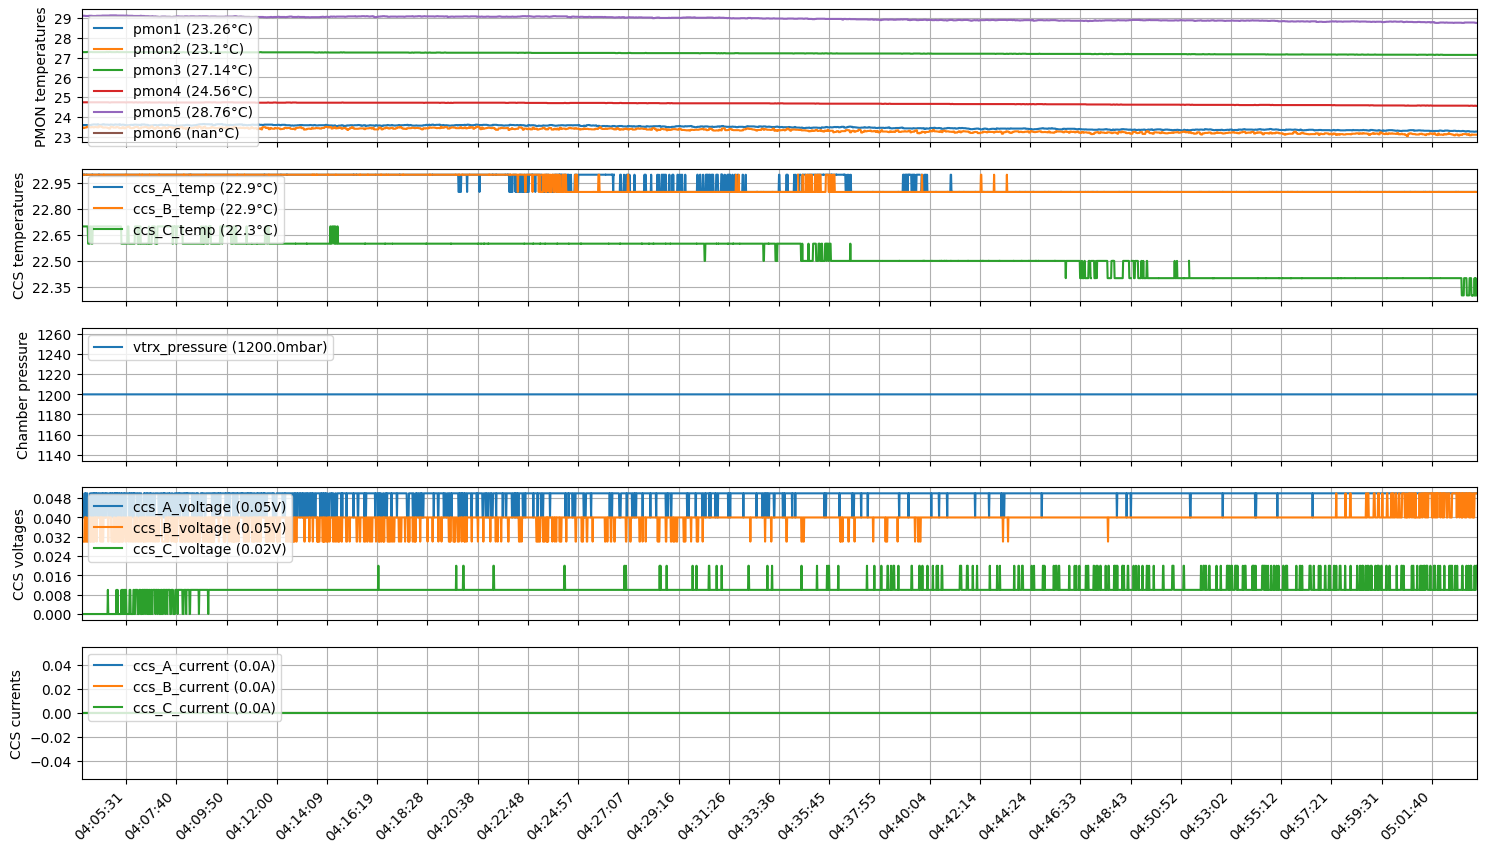

In [ ]:
# Main cell where graph generation is called repeatedly. To use the above settings, you must restart this cell only

try:
    lastLoopTime = time.perf_counter()
    # Read previous n webMonitor files (if available)
    files = glob.glob(webMonitor_path)
    print(files)
    if files:
        maxIndex = min(numInitWMFiles, len(files))
        for i in range(0, maxIndex) :
            files = sorted(files, key=os.path.getctime, reverse=True)
            getDataFromWebMonitorFile(files[i])

    while True :

        parsingStartTime = time.perf_counter()
        webMonitor_df, legacy_graph_dataframes= getAllData()
        parsingElapsedTime = time.perf_counter() - parsingStartTime

        
        graphGenStart = time.perf_counter()
        numPlots = getNumPlots(legacy_graph_dataframes, webMonitor_df)
        axs = getGraph(numPlots)
        graphingGenTime = time.perf_counter() - graphGenStart

        graphingStartTime = time.perf_counter()
        updateGraph(legacy_graph_dataframes, webMonitor_df, numPlots, axs)
        graphingElapsedTime = time.perf_counter() - graphingStartTime

        currentTime = datetime.now()
        print(f"Generated graph at {currentTime}")
        print(f"Log parsing took: {parsingElapsedTime}")
        print(f"Graph object generation took: {graphingGenTime}")
        print(f"Graphing took: {graphingElapsedTime}")

        totalTime = time.perf_counter() - parsingStartTime
        print(f"Total time: {totalTime}")
        print(f"Time since last loop: {time.perf_counter() - lastLoopTime}")

        lastLoopTime = time.perf_counter()
        # Make sure graph doesn't update too fast
        if(totalTime < .25) :
            time.sleep(.25)

        # Clear the screen right before displaying a new graph (no flashing if that's the only output)
        clear_output(True)

        

except KeyboardInterrupt:
    pass